# Diabetes Prediction using Machine Learning

This project uses machine learning to predict whether a person is diabetic based on medical diagnostic measurements.

## Objective

The objective is to build a classification model that predicts diabetes outcome using features such as glucose level, blood pressure, BMI, insulin level, age, and other health-related measurements.

In [69]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection and Analysis


In [70]:
# loading the diabetes dataset to a pandas dataframe
diabetes_dataset = pd.read_csv("data/diabetes.csv")

In [71]:
# Printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [72]:
# number of rows and coloumns in the dataset
diabetes_dataset.shape

(768, 9)

In [73]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [74]:
diabetes_dataset["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [75]:
diabetes_dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [76]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for column in zero_columns:
    print(column, ":", (diabetes_dataset[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


0--> Non Diabetic

1--> Diabetic

In [77]:
diabetes_dataset.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [78]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for column in zero_columns:
    diabetes_dataset[column] = diabetes_dataset[column].replace(
        0, diabetes_dataset[column].median()
    )

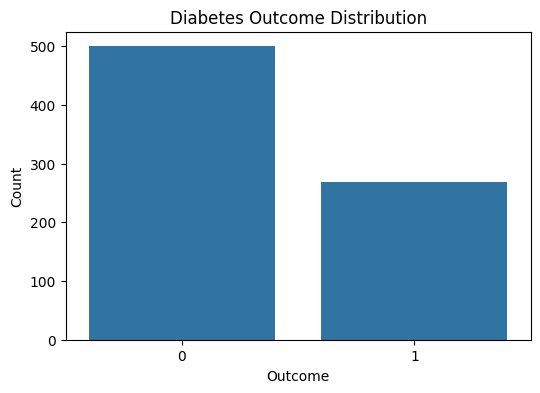

In [79]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=diabetes_dataset)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

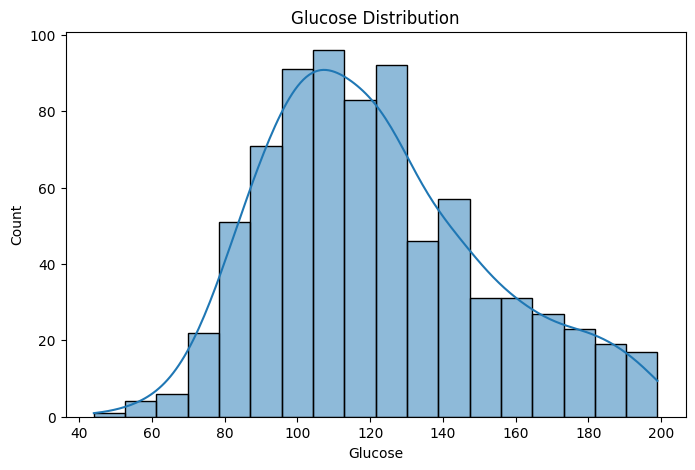

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(diabetes_dataset["Glucose"], kde=True)
plt.title("Glucose Distribution")
plt.show()

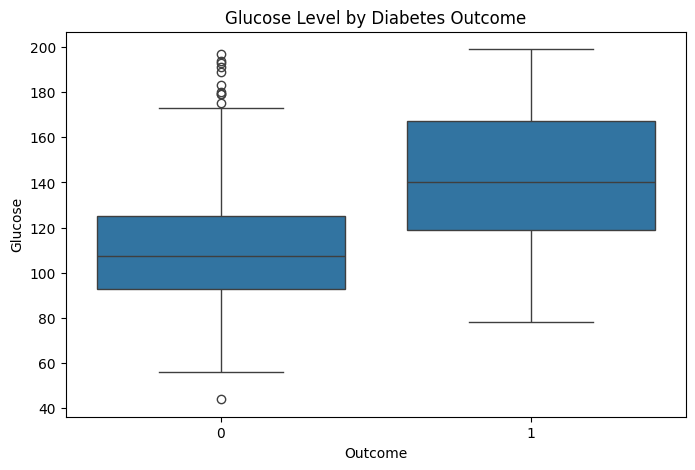

In [81]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="Glucose", data=diabetes_dataset)
plt.title("Glucose Level by Diabetes Outcome")
plt.show()

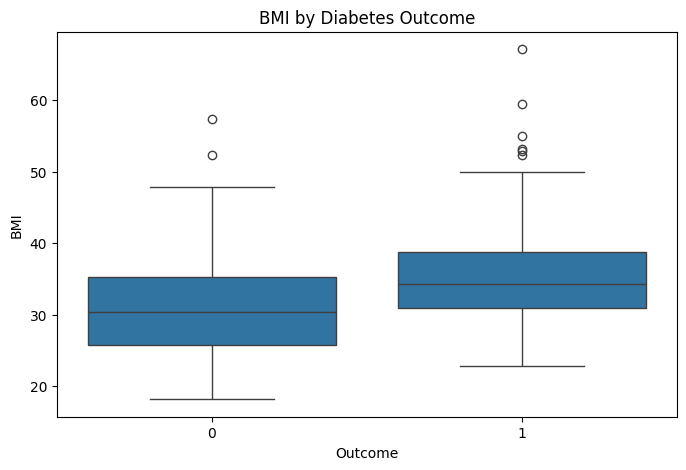

In [82]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="BMI", data=diabetes_dataset)
plt.title("BMI by Diabetes Outcome")
plt.show()

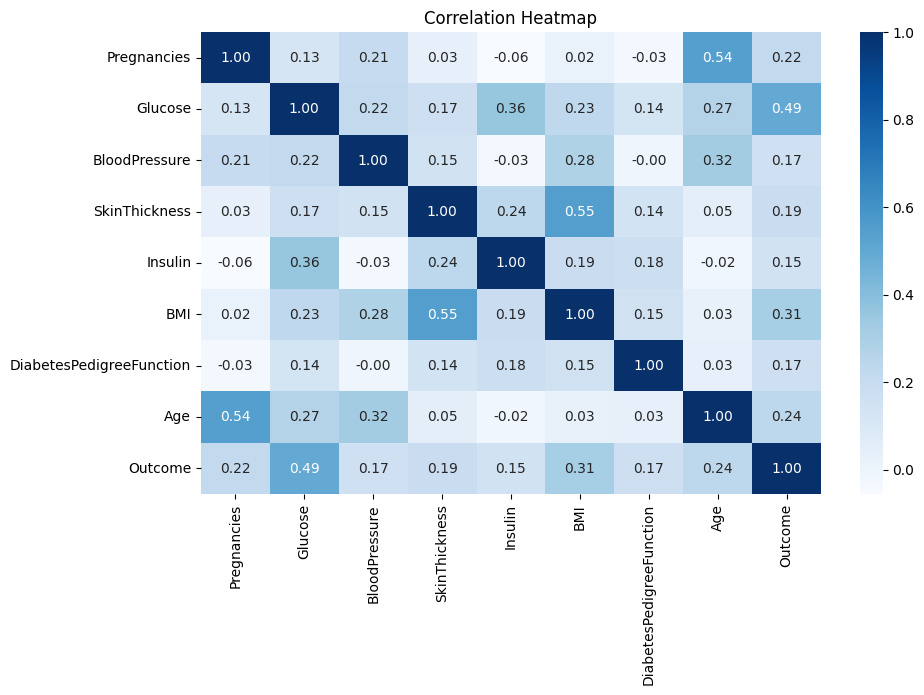

In [83]:
plt.figure(figsize=(10, 6))
sns.heatmap(diabetes_dataset.corr(), annot=True, cmap="Blues",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [84]:
X = diabetes_dataset.drop(columns="Outcome", axis=1)
Y = diabetes_dataset["Outcome"]

In [85]:
print(X.shape)
print(Y.shape)

(768, 8)
(768,)


Train Test Split

In [86]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

Data Standardization

In [87]:
scaler = StandardScaler()

In [88]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training the Model

In [89]:
classifier = svm.SVC(kernel = "linear")

In [90]:
classifier.fit(X_train_scaled, Y_train)

SVC(kernel='linear')

Model Evaluation

Accuracy Score

In [91]:
training_data_prediction = classifier.predict(X_train_scaled)
training_data_accuracy = accuracy_score(Y_train, training_data_prediction)

In [92]:
print("Accuracy score of the training data: ",training_data_accuracy)

Accuracy score of the training data:  0.7882736156351792


In [93]:
test_data_prediction = classifier.predict(X_test_scaled)
test_data_accuracy = accuracy_score(Y_test, test_data_prediction)

In [94]:
print(f"Accuracy of the test data: {(test_data_accuracy)*100:.3f}% ")

Accuracy of the test data: 70.779% 


In [95]:
print(classification_report(Y_test, test_data_prediction))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



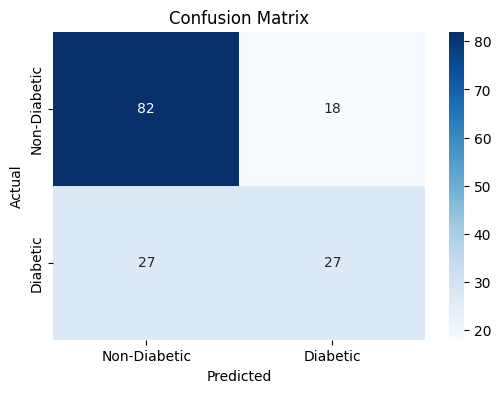

In [96]:
cm = confusion_matrix(Y_test, test_data_prediction)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [97]:
rbf_classifier = svm.SVC(kernel="rbf")
rbf_classifier.fit(X_train_scaled, Y_train)

rbf_prediction = rbf_classifier.predict(X_test_scaled)

print("RBF SVM Accuracy:", accuracy_score(Y_test, rbf_prediction))
print(classification_report(Y_test, rbf_prediction))

RBF SVM Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



In [98]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM"],
    "Accuracy": [
        accuracy_score(Y_test, test_data_prediction),
        accuracy_score(Y_test, rbf_prediction)
    ],
    "Precision": [
        precision_score(Y_test, test_data_prediction),
        precision_score(Y_test, rbf_prediction)
    ],
    "Recall": [
        recall_score(Y_test, test_data_prediction),
        recall_score(Y_test, rbf_prediction)
    ],
    "F1 Score": [
        f1_score(Y_test, test_data_prediction),
        f1_score(Y_test, rbf_prediction)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.707792,0.600000,0.500000,0.545455
1,RBF SVM,0.733766,0.644444,0.537037,0.585859


Making a Predictive System

In [99]:
sample = X.iloc[[0]]
sample_scaled = scaler.transform(sample)

prediction = rbf_classifier.predict(sample_scaled)

if prediction[0] == 0:
    print("Prediction: The person is not diabetic")
else:
    print("Prediction: The person is diabetic")

print("Actual:", "Diabetic" if Y.iloc[0] == 1 else "Non-Diabetic")

Prediction: The person is diabetic
Actual: Diabetic


## Conclusion

In this project, diabetes prediction was performed using machine learning.

- The dataset contained 768 records and 9 columns.
- The target variable indicated whether a person was diabetic or non-diabetic.
- Medically impossible zero values were identified and handled.
- Features were standardized using StandardScaler.
- Support Vector Machine models were trained and evaluated.
- The model achieved approximately 77% test accuracy.
- Additional metrics such as precision, recall, F1-score, and confusion matrix were used for better evaluation.

> Note: This project is for educational purposes only and should not be used for real medical diagnosis.

In [100]:
import pickle

with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(rbf_classifier, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)